In [21]:
##imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [22]:
##device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
##creating batches

Batch_size = 128
data_transform = transforms.Compose([transforms.ToTensor()])

##train_datasets = datasets.MNIST(root='./data', train=True, download=True, transform=data_transform)
train_datasets = datasets.FashionMNIST(root='./data', train=True, download=True, transform=data_transform)
train_loader = DataLoader(train_datasets, batch_size=Batch_size, shuffle=True)

In [24]:
##VAE CLass
latent_dim = 64

class VAE(nn.Module):
  def __init__(self, input_dim = 784, hidden_dim = 256, latent_dim = latent_dim):
    super().__init__()

    ##Encoder
    self.fullyConnectedLayer1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)##check notes for maths behind it

    ##Decoder
    self.fullyConnectedLayer2 = nn.Linear(latent_dim, hidden_dim)
    self.fullyConnectedLayer3 = nn.Linear(hidden_dim, input_dim)##check notes for maths behind it

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

    ##before forward pass we need to define the encode, decode and reparameterisation term

  #forward pass through the encoder
  def encode(self, x):
    h = self.relu(self.fullyConnectedLayer1(x))
    mu = self.fc_mu(h)
    logvar = self.fc_logvar(h)
    return mu, logvar

  #picking "Z", i.e. sampling "Z" from the N(mu, sigma) distribution
  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar) ##essentially taking the square root of the exponent
    eps = torch.randn_like(std) ##sampling from the same distribution -> randn_like is to sample another random distributiin which comes from the same distribution
    z = mu + (eps*std) ## see the notes.
    return z ##this is the random z that we sampled



  #forward pass through the decoder
  def decode(self, x):
    h = self.relu(self.fullyConnectedLayer2(x)) # Changed z to x here
    final_output = self.sigmoid(self.fullyConnectedLayer3(h))
    return final_output


  ##forward pass
  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_reconstructed = self.decode(z)
    return x_reconstructed, mu, logvar

In [25]:
##calculating the loss

def vae_loss(recon_x, x, mu, logvar):
  # Reconstruction loss: sum MSE for each sample, then average over batch
  # Using reduction='sum' first sums over all elements (batch_size * 784), then divide by batch_size
  reconstruction_loss = nn.functional.mse_loss(recon_x, x, reduction='sum') / x.size(0)

  # KL divergence for each sample (sum over latent dimensions) and then averaged over the batch
  # Formula: 0.5 * sum(mu^2 + sigma^2 - log(sigma^2) - 1)
  # Here logvar = log(sigma^2), so sigma^2 = exp(logvar)
  kl_div_per_sample = 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1, dim=1)
  kl_loss = torch.mean(kl_div_per_sample)

  return reconstruction_loss + kl_loss

In [26]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [27]:
epochs = 20

model.train()

for epoch in range(epochs):
  total_loss = 0

  for x, _ in (train_loader):

    x = x.view(-1, 784).to(device)
    optimizer.zero_grad() ## this is done for every batch separately so we cant put it outside

    x_reconstructed, mu, logvar = model(x) ## these are coming from the input
    loss = vae_loss(x_reconstructed, x, mu, logvar)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  # Calculate average loss per batch (which is effectively average loss per sample, given loss function returns average per sample)
  avg_loss = total_loss/len(train_loader)

  # print(f"Epoch: {epoch+1}, Loss: {total_loss/len(train_loader.dataset)}")
  print(f"Epoch : [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch : [1/20], Loss: 44.7925
Epoch : [2/20], Loss: 32.2896
Epoch : [3/20], Loss: 29.0692
Epoch : [4/20], Loss: 27.8246
Epoch : [5/20], Loss: 27.1466
Epoch : [6/20], Loss: 26.6977
Epoch : [7/20], Loss: 26.3325
Epoch : [8/20], Loss: 26.1116
Epoch : [9/20], Loss: 25.8847
Epoch : [10/20], Loss: 25.6918
Epoch : [11/20], Loss: 25.5091
Epoch : [12/20], Loss: 25.3963
Epoch : [13/20], Loss: 25.3008
Epoch : [14/20], Loss: 25.1717
Epoch : [15/20], Loss: 25.0817
Epoch : [16/20], Loss: 25.0255
Epoch : [17/20], Loss: 24.9411
Epoch : [18/20], Loss: 24.8770
Epoch : [19/20], Loss: 24.8021
Epoch : [20/20], Loss: 24.7572


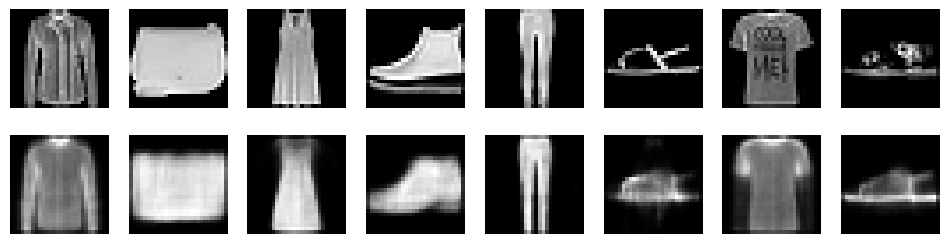

In [28]:
##plotting the code

model.eval()

with torch.no_grad():
  x, _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)

  x_reconstructed, _, _ = model(x)
  x = x.cpu()
  x_reconstructed = x_reconstructed.cpu()

  n = 8
  plt.figure(figsize = (12,3))
  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28,28), cmap = "gray")
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_reconstructed[i].view(28,28), cmap = "gray")
    plt.axis("off") # Changed assignment to function call

  plt.show()

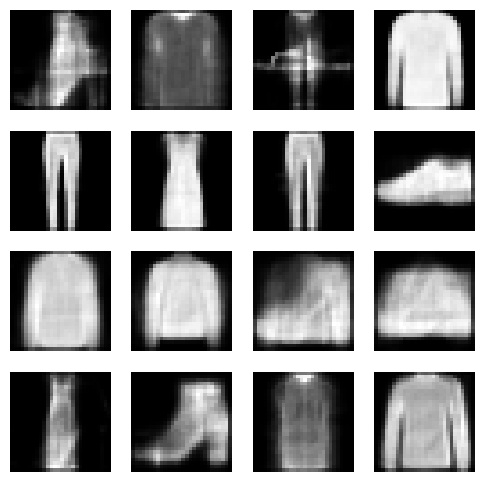

In [29]:
with torch.no_grad():
  z=torch.randn(16, latent_dim).to(device)
  samples = model.decode(z).cpu()

  plt.figure(figsize = (6,6))
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i].view(28,28), cmap = "gray")
    plt.axis("off")
  plt.show()